# 🔬 Bài 6: Ứng dụng — Đếm Tế Bào Trong Ảnh Y Khoa
**Môn học**: E1402 - Computer Vision  
**Chủ đề**: Ứng dụng xử lý ảnh nhị phân trong y khoa

---

### 🎯 Mục tiêu bài học:
- Hiểu pipeline xử lý ảnh y khoa: **RGB → Grayscale → Binary → Contour → Đếm**
- Thực hành **ngưỡng hóa Otsu** (tự động chọn ngưỡng)
- Sử dụng **Morphological Operations** để làm sạch ảnh nhị phân
- Áp dụng **findContours** để phát hiện và đếm đối tượng

### 📋 Kiến thức cần có:
- Bài 5: Các hệ màu cơ bản (RGB, Grayscale, Binary)

---
## ⚙️ Phần 1: Cài đặt thư viện
Chạy ô này **một lần** để import các thư viện cần thiết.

In [1]:
import cv2                          # OpenCV - thư viện xử lý ảnh chính
import numpy as np                  # NumPy - xử lý mảng số
import matplotlib.pyplot as plt     # Matplotlib - hiển thị ảnh
import random                       # Random - tạo dữ liệu ngẫu nhiên
import urllib.request               # Tải ảnh từ URL

# Kiểm tra môi trường
try:
    import google.colab
    COLAB = True
    print('✅ Đang chạy trên Google Colab')
except:
    COLAB = False
    print('✅ Đang chạy trên máy local')

# --- Hàm tiện ích ---
def tai_anh_url(url):
    """Tải ảnh từ URL và trả về dạng BGR (OpenCV)"""
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    resp = urllib.request.urlopen(req)
    arr = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

def hien_thi(ds_anh, ds_ten, figsize=(15, 5), cmap_list=None):
    """Hiển thị nhiều ảnh cạnh nhau"""
    n = len(ds_anh)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i, (anh, ten) in enumerate(zip(ds_anh, ds_ten)):
        cmap = cmap_list[i] if cmap_list else None
        if cmap is None and len(anh.shape) == 3:
            axes[i].imshow(cv2.cvtColor(anh, cv2.COLOR_BGR2RGB))
        else:
            axes[i].imshow(anh, cmap=cmap)
        axes[i].set_title(ten, fontsize=12, fontweight='bold')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

print('📦 Đã import xong tất cả thư viện!')

✅ Đang chạy trên máy local
📦 Đã import xong tất cả thư viện!


---
## 📖 Phần 2: Lý thuyết — Pipeline đếm tế bào

### 2.1 Quy trình tổng quát
```
Ảnh kính hiển vi  →  Ảnh xám   →  Ngưỡng hóa  →  Morphology  →  findContours  →  Đếm
    (RGB/BGR)      (Grayscale)    (Otsu/Binary)   (Làm sạch)    (Tìm viền)     (Kết quả)
```

### 2.2 Tại sao cần từng bước?

| Bước | Tên gọi | Mục đích |
|:---:|---|---|
| 1 | **Grayscale** | Giảm từ 3 kênh → 1 kênh, đơn giản hóa xử lý |
| 2 | **Otsu Threshold** | Tự động tìm ngưỡng tối ưu để tách tế bào khỏi nền |
| 3 | **Morphology** | Loại nhiễu nhỏ (OPEN) và lấp lỗ trống (CLOSE) |
| 4 | **findContours** | Tìm đường viền bao quanh từng tế bào |
| 5 | **Lọc diện tích** | Bỏ contour quá nhỏ (nhiễu) hoặc quá lớn (gộp nhóm) |

### 2.3 Morphological Operations
```
MORPH_OPEN  = Erosion + Dilation  →  Loại bỏ nhiễu nhỏ (chấm trắng thừa)
MORPH_CLOSE = Dilation + Erosion  →  Lấp khe hở nhỏ (lỗ đen trong tế bào)
```

> 💡 **Kernel hình elip** (MORPH_ELLIPSE) phù hợp nhất cho tế bào vì tế bào thường có dạng **tròn/bầu dục**.

---
## 🧪 Phần 3: Tạo dữ liệu — Mô phỏng ảnh tế bào máu

Trong thực tế, ảnh lấy từ **kính hiển vi**. Ở đây ta mô phỏng ảnh tế bào máu 
với đặc điểm:
- **Nền sáng** (mô phỏng ánh sáng kính hiển vi)
- **Tế bào tím-hồng** (mô phỏng nhuộm Wright-Giemsa)
- **Nhân tế bào** (chấm đậm ở giữa mỗi tế bào)
- **Nhiễu nền** (texture giấy/kính)

> 🔑 Phần tạo dữ liệu **tách riêng** để dễ thay thế bằng ảnh thực tế sau này.

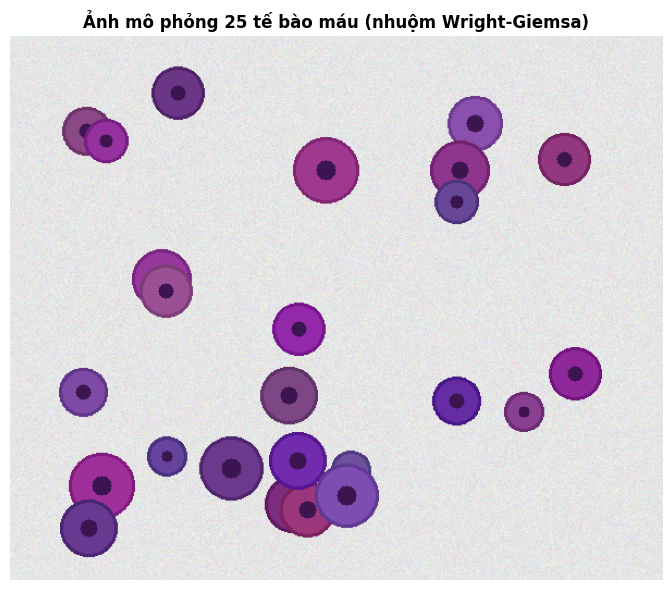

📋 Kích thước ảnh: (500, 600, 3)
📋 Số tế bào đã tạo: 25


In [2]:
# ============================================================
# 📂 TẠO DỮ LIỆU: Mô phỏng ảnh tế bào máu dưới kính hiển vi
# ============================================================
random.seed(42)  # Cố định seed để kết quả nhất quán

def tao_anh_te_bao(so_te_bao=25, kich_thuoc=(500, 600)):
    """
    Tạo ảnh mô phỏng tế bào máu dưới kính hiển vi.
    
    Tham số:
        so_te_bao: số lượng tế bào cần tạo
        kich_thuoc: (chiều cao, chiều rộng) của ảnh
    Trả về:
        anh: ảnh BGR (OpenCV format)
        so_te_bao: số tế bào thực tế đã tạo
    """
    h, w = kich_thuoc
    
    # Nền sáng (mô phỏng ánh sáng kính hiển vi)
    anh = np.ones((h, w, 3), dtype=np.uint8) * 230
    
    # Thêm nhiễu nền (texture tự nhiên)
    nhieu = np.random.randint(-15, 15, anh.shape, dtype=np.int16)
    anh = np.clip(anh.astype(np.int16) + nhieu, 0, 255).astype(np.uint8)
    
    # Vẽ từng tế bào
    for _ in range(so_te_bao):
        # Vị trí ngẫu nhiên (tránh viền)
        x = random.randint(40, w - 40)
        y = random.randint(40, h - 40)
        ban_kinh = random.randint(15, 30)
        
        # Màu tế bào: tím-hồng (mô phỏng nhuộm Wright-Giemsa)
        b = random.randint(120, 180)  # Blue cao
        g = random.randint(40, 80)    # Green thấp
        r = random.randint(100, 160)  # Red trung bình
        
        # Thân tế bào
        cv2.circle(anh, (x, y), ban_kinh, (b, g, r), -1)
        # Viền tế bào (đậm hơn)
        cv2.circle(anh, (x, y), ban_kinh, (b-30, g-20, r-30), 2)
        # Nhân tế bào (chấm đậm ở giữa)
        cv2.circle(anh, (x, y), ban_kinh // 3, (80, 20, 60), -1)
    
    return anh, so_te_bao

# --- Tạo ảnh mô phỏng ---
anh_te_bao, so_thuc = tao_anh_te_bao(so_te_bao=25)

hien_thi([anh_te_bao], 
         [f'Ảnh mô phỏng {so_thuc} tế bào máu (nhuộm Wright-Giemsa)'], 
         figsize=(8, 6))
print(f'📋 Kích thước ảnh: {anh_te_bao.shape}')
print(f'📋 Số tế bào đã tạo: {so_thuc}')

---
## 🔬 Phần 4: Xử lý — Pipeline đếm tế bào

Bây giờ ta áp dụng pipeline xử lý ảnh từng bước.

In [3]:
# ============================================================
# 🔬 XỬ LÝ: Pipeline đếm tế bào
# ============================================================

# --- Bước 1: Chuyển sang ảnh xám ---
anh_xam = cv2.cvtColor(anh_te_bao, cv2.COLOR_BGR2GRAY)
print(f'Bước 1: Ảnh xám — shape = {anh_xam.shape}')

# --- Bước 2: Ngưỡng hóa Otsu (đảo ngược vì tế bào TỐI hơn nền) ---
nguong, anh_nhi_phan = cv2.threshold(
    anh_xam, 0, 255, 
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU  # INV = đảo (tế bào → trắng)
)
print(f'Bước 2: Ngưỡng Otsu tự động = {nguong:.0f}')

# --- Bước 3: Morphology — Làm sạch ---
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
anh_sach = cv2.morphologyEx(anh_nhi_phan, cv2.MORPH_OPEN, kernel, iterations=2)  # Loại nhiễu
anh_sach = cv2.morphologyEx(anh_sach, cv2.MORPH_CLOSE, kernel, iterations=1)     # Lấp lỗ
print(f'Bước 3: Morphology — OPEN(2 lần) + CLOSE(1 lần)')

# --- Bước 4: Tìm contour ---
contours, _ = cv2.findContours(anh_sach, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f'Bước 4: Tìm được {len(contours)} contour')

# --- Bước 5: Lọc theo diện tích ---
DIEN_TICH_MIN = 200  # pixel² — bỏ nhiễu quá nhỏ
te_bao_ok = [c for c in contours if cv2.contourArea(c) > DIEN_TICH_MIN]
print(f'Bước 5: Sau lọc (>{DIEN_TICH_MIN}px²) → {len(te_bao_ok)} tế bào')
print(f'         Loại bỏ {len(contours) - len(te_bao_ok)} nhiễu nhỏ')

Bước 1: Ảnh xám — shape = (500, 600)
Bước 2: Ngưỡng Otsu tự động = 110
Bước 3: Morphology — OPEN(2 lần) + CLOSE(1 lần)
Bước 4: Tìm được 16 contour
Bước 5: Sau lọc (>200px²) → 16 tế bào
         Loại bỏ 0 nhiễu nhỏ


---
## 📊 Phần 5: Kết quả — Hiển thị pipeline

/var/folders/gn/__q44dqx4g94_zn16nx2720w0000gn/T/ipykernel_6735/1532166549.py:35: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/phongdang/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


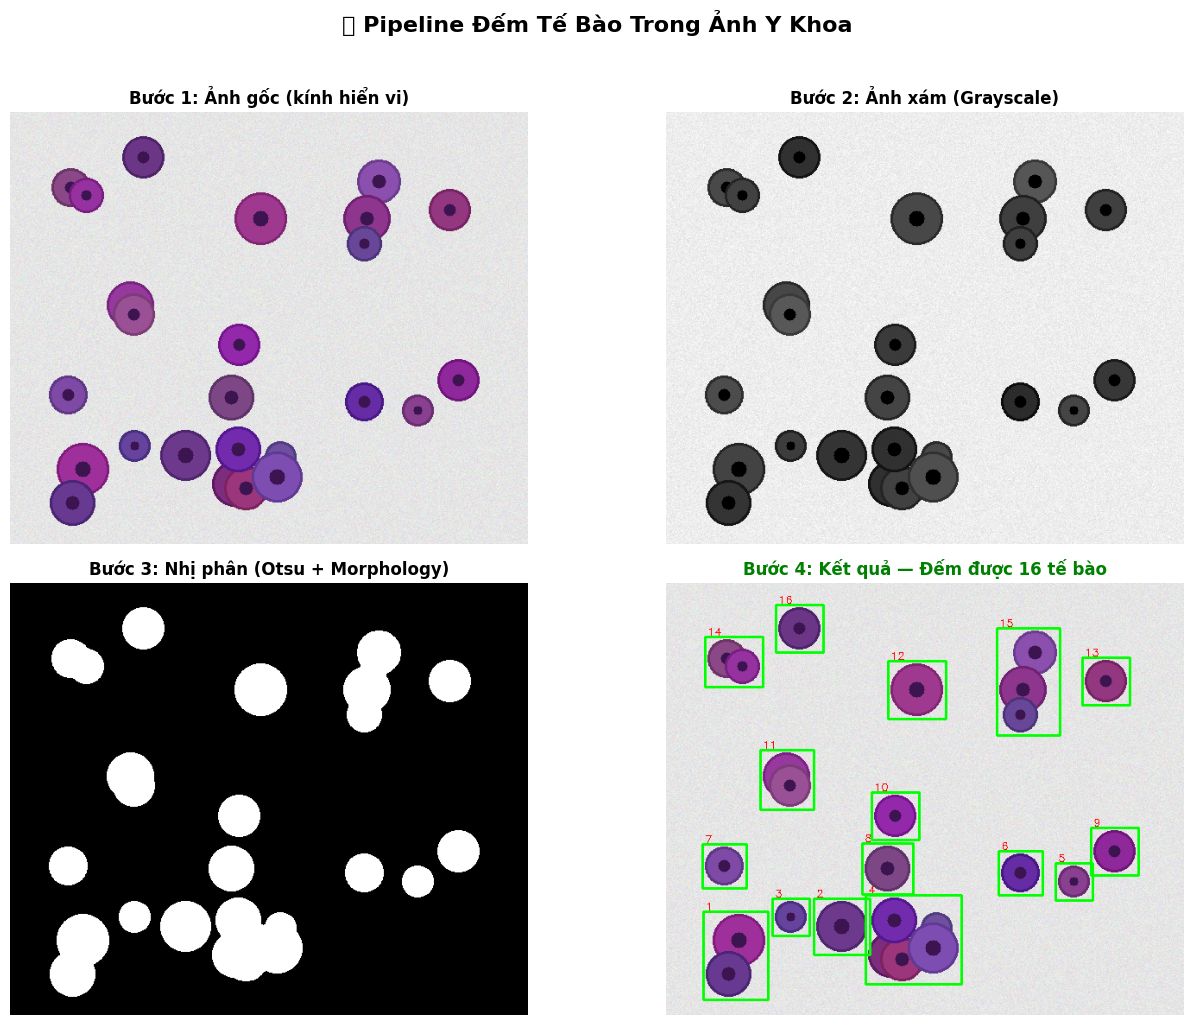

📊 KẾT QUẢ:
   Số tế bào thực tế:    25
   Số tế bào phát hiện:  16
   Contour tổng cộng:    16
   Nhiễu đã loại bỏ:     0


In [4]:
# ============================================================
# 📊 HIỂN THỊ: Kết quả từng bước
# ============================================================

# Vẽ kết quả lên ảnh gốc
anh_ket_qua = anh_te_bao.copy()
for i, contour in enumerate(te_bao_ok):
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(anh_ket_qua, (x-3, y-3), (x+w+3, y+h+3), (0, 255, 0), 2)
    cv2.putText(anh_ket_qua, str(i+1), (x, y-5), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

# Hiển thị 4 bước
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].imshow(cv2.cvtColor(anh_te_bao, cv2.COLOR_BGR2RGB))
axes[0][0].set_title('Bước 1: Ảnh gốc (kính hiển vi)', fontsize=12, fontweight='bold')

axes[0][1].imshow(anh_xam, cmap='gray')
axes[0][1].set_title('Bước 2: Ảnh xám (Grayscale)', fontsize=12, fontweight='bold')

axes[1][0].imshow(anh_sach, cmap='gray')
axes[1][0].set_title('Bước 3: Nhị phân (Otsu + Morphology)', fontsize=12, fontweight='bold')

axes[1][1].imshow(cv2.cvtColor(anh_ket_qua, cv2.COLOR_BGR2RGB))
axes[1][1].set_title(f'Bước 4: Kết quả — Đếm được {len(te_bao_ok)} tế bào', 
                     fontsize=12, fontweight='bold', color='green')

for row in axes:
    for ax in row:
        ax.axis('off')

plt.suptitle('🔬 Pipeline Đếm Tế Bào Trong Ảnh Y Khoa', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tóm tắt
print('=' * 50)
print(f'📊 KẾT QUẢ:')
print(f'   Số tế bào thực tế:    {so_thuc}')
print(f'   Số tế bào phát hiện:  {len(te_bao_ok)}')
print(f'   Contour tổng cộng:    {len(contours)}')
print(f'   Nhiễu đã loại bỏ:     {len(contours) - len(te_bao_ok)}')
print('=' * 50)

---
## 🧪 Phần 6: Thử nghiệm — Thay đổi tham số

Hãy thử thay đổi các tham số bên dưới và quan sát kết quả.

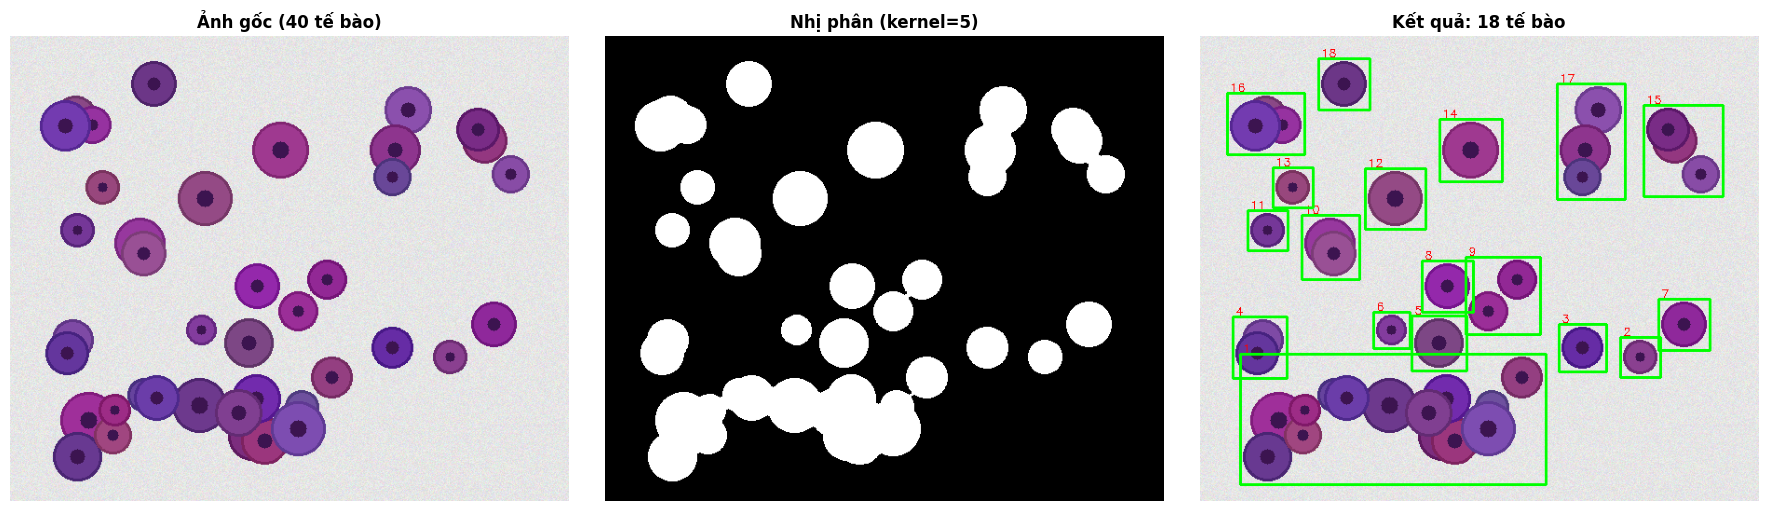

💡 Tham số: kernel=5, OPEN=2, CLOSE=1, diện tích min=200
📊 Thực tế: 40 | Phát hiện: 18 | Sai lệch: 22


In [5]:
# ============================================================
# 🔧 THỬ NGHIỆM: Thay đổi tham số
# ============================================================

# 🔧 THAY ĐỔI Ở ĐÂY:
SO_TE_BAO = 40          # Thử: 10, 25, 40, 60
KERNEL_SIZE = 5         # Thử: 3, 5, 7, 9
DIEN_TICH_MIN = 200     # Thử: 50, 100, 200, 500
OPEN_ITER = 2           # Thử: 1, 2, 3
CLOSE_ITER = 1          # Thử: 0, 1, 2

# Tạo ảnh mới
random.seed(42)
anh_new, so_new = tao_anh_te_bao(so_te_bao=SO_TE_BAO)

# Xử lý
xam = cv2.cvtColor(anh_new, cv2.COLOR_BGR2GRAY)
_, nhi_phan = cv2.threshold(xam, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (KERNEL_SIZE, KERNEL_SIZE))
sach = cv2.morphologyEx(nhi_phan, cv2.MORPH_OPEN, k, iterations=OPEN_ITER)
sach = cv2.morphologyEx(sach, cv2.MORPH_CLOSE, k, iterations=CLOSE_ITER)
cts, _ = cv2.findContours(sach, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cts_ok = [c for c in cts if cv2.contourArea(c) > DIEN_TICH_MIN]

# Vẽ kết quả
kq = anh_new.copy()
for i, c in enumerate(cts_ok):
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(kq, (x-3,y-3), (x+w+3,y+h+3), (0,255,0), 2)
    cv2.putText(kq, str(i+1), (x,y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)

hien_thi([anh_new, sach, kq],
         [f'Ảnh gốc ({so_new} tế bào)', 
          f'Nhị phân (kernel={KERNEL_SIZE})',
          f'Kết quả: {len(cts_ok)} tế bào'],
         figsize=(18, 5),
         cmap_list=[None, 'gray', None])

print(f'💡 Tham số: kernel={KERNEL_SIZE}, OPEN={OPEN_ITER}, CLOSE={CLOSE_ITER}, diện tích min={DIEN_TICH_MIN}')
print(f'📊 Thực tế: {so_new} | Phát hiện: {len(cts_ok)} | Sai lệch: {abs(so_new - len(cts_ok))}')

---
## 📝 Tổng kết

### Pipeline đếm tế bào:
```
RGB → Grayscale → Otsu Threshold → Morphology (OPEN + CLOSE) → findContours → Lọc diện tích → Đếm
```

### Các hàm OpenCV quan trọng:
| Hàm | Chức năng |
|---|---|
| `cv2.cvtColor(img, COLOR_BGR2GRAY)` | Chuyển sang ảnh xám |
| `cv2.threshold(img, 0, 255, THRESH_BINARY_INV + THRESH_OTSU)` | Ngưỡng hóa Otsu tự động |
| `cv2.getStructuringElement(MORPH_ELLIPSE, (5,5))` | Tạo kernel hình elip |
| `cv2.morphologyEx(img, MORPH_OPEN, kernel)` | Loại nhiễu nhỏ |
| `cv2.morphologyEx(img, MORPH_CLOSE, kernel)` | Lấp lỗ trống |
| `cv2.findContours(img, RETR_EXTERNAL, ...)` | Tìm contour ngoài cùng |
| `cv2.contourArea(contour)` | Tính diện tích contour |
| `cv2.boundingRect(contour)` | Tìm hình chữ nhật bao quanh |

### Lưu ý thực tế:
- Ảnh y khoa thực cần **tiền xử lý phức tạp hơn** (cân bằng ánh sáng, lọc nhiễu)
- Tế bào dính nhau cần dùng **Watershed Algorithm** để tách
- Trong nghiên cứu thực tế, thường dùng **Deep Learning** (U-Net, Mask R-CNN) để đạt độ chính xác cao hơn